# K2: is the host-entry effect host-specific, or just common words?

**POST-CONFIRMATION EXPLORATORY evaluation (CPU only, no network needed apart from loading the demo data).**

When a concept enters a new subfield *d*, some of its partner keywords already have a high **host share**: a large fraction of their pre-entry literature sits in *d*. An earlier confirmed result (D2) is that a higher mean host share (**A_cont**) predicts more uptake of the concept in *d* by newcomers.

K2 tests a rival explanation, **generic accessibility**: maybe host-leaning partners are just frequent, widely used words that make any paper findable. The test adds two standard term-generality proxies:
- **G_H**: the tag-weighted normalised subfield entropy (how dispersed a partner is across subfields);
- **G_F**: the tag-weighted log block frequency (how common a partner is);

It then asks how much of the A_cont effect is **retained** once they are controlled for: retention = b_A(M1) / b_A(M0). It also uses the lift form **A_lift = ln(A_cont / s_dB)**. The frozen decision rule reads **HOST-SPECIFIC** if the A_lift CI excludes 1 *and* retention ≥ 0.5, and **GENERIC ACCESSIBILITY** if retention < 0.5.

**What this notebook runs.** The artifact's `eval.py` is the *final assembly* step. It computes **no new coefficient**. It reads the recorded K2 result files and then:
1. draws the three figures: F1 forest plot, F2 retention, F3 within-FE generality scatter;
2. flattens the results into ~300 aggregate metrics;
3. builds the two example datasets (`k2_rows`, `entry_generality`) of the `exp_eval_sol_out` schema.

The upstream PPML fits (bootstraps, 24,000 randomisation refits, and so on) are not re-run here. This notebook loads those recorded outputs from `mini_demo_data.json`, which is a curated subset:
- all summary JSONs;
- 98 of the 123 model rows;
- 15 concepts per fold of the 5,086-event partner-generality table.

The code below is `eval.py` split into cells, with only the file reads changed to use the loaded `data`.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, scipy, matplotlib — pre-installed on Colab, install locally only (at Colab's versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'matplotlib==3.10.0')

## Imports
The original `eval.py` import block, plus `IPython.display` so the saved figures can be shown inline.

In [2]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402
import pandas as pd  # noqa: E402
from loguru import logger  # noqa: E402

# notebook-only: display the saved PNG figures inline
from IPython.display import Image, display

## Load the demo data
The loader tries the GitHub raw URL first (this works in Colab) and falls back to a local `mini_demo_data.json`.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8892b7-occupancy-is-not-integration-for-new/fork/run_WV-8ZZxjzY5t/round-5/evaluation-7/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print({k: (len(v) if isinstance(v, (list, dict)) else v) for k, v in data.items() if k != "description"})

Mini demo input for K2 eval.py (host-specific vs generic accessibility). All summary JSONs are the recorded K2 result files; k2_rows is a <=100-row subset of results/k2_rows.csv; partner_generality is a concept-stratified subset (15 concepts/fold) of results/partner_generality.parquet.
{'k2_summary': 8, 'k2_power': 4, 'k2_placebo_host': 6, 'audit_k2': 7, 'gates': 4, 'k2_descriptives': 3, 'k2_s2b_diagnostic': 3, 'k2_spec': 24, 'k2_rows': 98, 'partner_generality': 651}


## Config
`eval.py` has no iteration counts, because it only assembles results that were already computed. The only tunable parameters are:
- `N_CONCEPTS_PER_FOLD`: how many concepts per fold of the partner-generality table enter the F3 scatter and the `entry_generality` dataset. The demo file holds 15 per fold; the original run used **all** 5,086 events (about 104 to 245 concepts per fold).
- `FIG_DPI`: the resolution of the saved figures. The original is 200.

In [5]:
N_CONCEPTS_PER_FOLD = 15   # demo file holds 15/fold; original: all concepts (full results/partner_generality.parquet)
FIG_DPI = 200              # original: 200

## Setup: paths, logging and constants
These are the module-level constants of `eval.py`. The only change is that `WS` is the notebook's working directory instead of `Path(__file__).resolve().parent`. Figures go to `figures/` and the log goes to `logs/eval.log`.

`VCODE` maps the verdict labels to numbers for the flat metrics: HOST-SPECIFIC = 1, MIXED = 0, GENERIC = −1.

In [6]:
WS = Path.cwd()  # was: Path(__file__).resolve().parent
RES, FIGS, AUD = WS / "results", WS / "figures", WS / "audit"
FIGS.mkdir(exist_ok=True)
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
logger.add(WS / "logs" / "eval.log", rotation="30 MB", level="DEBUG")
FOLDS = ["screen", "heldout", "mesh"]
FNAME = {"screen": "Screen (main)", "heldout": "Held-out (main)", "mesh": "MeSH", "pooled": "IVW pooled"}
COL = {"screen": "#1f77b4", "heldout": "#ff7f0e", "mesh": "#2ca02c", "pooled": "#222222"}
VCODE = {"HOST-SPECIFIC": 1, "MIXED": 0, "GENERIC ACCESSIBILITY": -1, "NOT DETERMINED": np.nan}


def num(x) -> float | None:
    try:
        v = float(x)
    except (TypeError, ValueError):
        return None
    return v if np.isfinite(v) else None

## F1: forest plot of the K2 model terms
This plots, for each fold and for the IVW pool, the IRR per SD with its 95% CI for:
- the focal terms: M0 A_cont, M1 A_cont | G, M2 A_lift, M3 A_lift | G;
- the two generality controls in M1: G_H and G_F.

The generic-accessibility story predicts that A_cont shrinks towards 1 once G is added.

In [7]:
def fig_forest(rows: pd.DataFrame) -> None:
    items = [("M0", "A_cont", "M0: A_cont"), ("M1", "A_cont", "M1: A_cont | G"), ("M2", "A_lift", "M2: A_lift"),
             ("M3", "A_lift", "M3: A_lift | G"), ("M1", "G_H", "M1: G_H"), ("M1", "G_F", "M1: G_F")]
    fig, ax = plt.subplots(figsize=(8, 7.5))
    yt, yl, y = [], [], 0
    for m, v, lab in items:
        for f in FOLDS + ["pooled_IVW"]:
            r = rows[(rows.fold == f) & (rows.model == m) & (rows["var"] == v)]
            if not len(r):
                continue
            r = r.iloc[0]
            key = "pooled" if f == "pooled_IVW" else f
            ax.errorbar(r.irr_sd, y, xerr=[[r.irr_sd - r.irr_sd_lo], [r.irr_sd_hi - r.irr_sd]], fmt="D" if key ==
                        "pooled" else "o", color=COL[key], ms=6 if key == "pooled" else 4, capsize=2)
            yt.append(y)
            yl.append(f"{lab}  [{FNAME[key]}]")
            y -= 1
        y -= 0.6
    ax.axvline(1, color="grey", lw=0.8, ls="--")
    ax.set_xscale("log")
    ax.set_yticks(yt)
    ax.set_yticklabels(yl, fontsize=7.5)
    ax.set_xlabel("IRR per SD (95% CI; CRV1 t(G-1) per fold, IVW normal pooled)")
    ax.set_title("K2: host share vs partner generality (co-primary FE, Y_strict)\nPOST-CONFIRMATION EXPLORATORY",
                 fontsize=10)
    fig.tight_layout()
    for ext in ("png", "pdf"):
        fig.savefig(FIGS / f"F1_k2_forest.{ext}", dpi=FIG_DPI)
    plt.close(fig)

## F2: retention against the design-analysis ranges
Each point is the observed retention b_A(M1)/b_A(M0), with its 95% concept-bootstrap CI.

The shaded bars are the simulated retention ranges from the Step-3 design analysis:
- blue: under a host-specific data-generating process (DGP);
- orange: under a generic DGP.

The red line is the frozen rule's threshold of 0.5.

In [8]:
def fig_retention(summ: dict, power: dict) -> None:
    fig, ax = plt.subplots(figsize=(7.5, 4.8))
    keys = FOLDS + ["pooled"]
    for i, k in enumerate(keys):
        d = summ["pooled"] if k == "pooled" else summ["folds"][k]
        pw = power["pooled"] if k == "pooled" else power["folds"][k]
        for dgp, off, c in (("DGP_S", -0.25, "#9ecae1"), ("DGP_G", 0.25, "#fdae6b")):
            q = (pw.get(dgp) or {}).get("ret_q025_q975")
            if q:
                ax.fill_between([i + off - 0.1, i + off + 0.1], q[0], q[1], color=c, alpha=0.8,
                                label=("simulated ret range, host-specific DGP" if dgp == "DGP_S" else
                                       "simulated ret range, generic DGP") if i == 0 else None)
        lo, hi = d["ret_ci"]
        ax.errorbar(i, d["ret"], yerr=[[d["ret"] - lo], [hi - d["ret"]]], fmt="D" if k == "pooled" else "o",
                    color=COL[k], capsize=4, ms=7)
        ax.text(i + 0.06, d["ret"], f"{d['ret']:.2f}", fontsize=8, va="bottom")
    ax.axhline(0.5, color="red", ls="--", lw=1, label="rule threshold 0.5")
    ax.axhline(1.0, color="grey", ls=":", lw=0.8)
    ax.set_xticks(range(len(keys)))
    ax.set_xticklabels([FNAME[k] for k in keys])
    ax.set_ylabel("retention b_A(M1) / b_A(M0)\n(95% concept-bootstrap CI)")
    ax.set_title("Share of the A_cont effect retained after partner-generality controls", fontsize=10)
    ax.legend(fontsize=7, loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3, frameon=False)
    fig.tight_layout()
    for ext in ("png", "pdf"):
        fig.savefig(FIGS / f"F2_retention.{ext}", dpi=FIG_DPI)
    plt.close(fig)

## F3: within-FE scatter of host share against generality
The generic story predicts that host share and generality move *together*. The check residualises A_cont, G_H and G_F on the concept + e + d fixed effects, then correlates what is left.

`eval.py` imports the exact FE projection `_demean` from the vendored module `d2/src/ppml.py`. Here that function is copied verbatim into the notebook, so `within()` calls it directly instead of doing `sys.path.insert(...); import ppml`. `_demean` solves a sparse least-squares problem, (D'WD + εI) c = D'W M with D the stacked FE dummies, and returns M − Dc.

In [9]:
# --- vendored verbatim from d2/src/ppml.py (eval.py imports it as ppml._demean) ---
def _demean(M: np.ndarray, w: np.ndarray, fes: list[np.ndarray]) -> np.ndarray:
    """Exact weighted projection off the FE space: solve (D'WD + eps I) c = D'W M with a sparse LU (D = [D1 D2])."""
    from scipy import sparse
    from scipy.sparse.linalg import splu
    n = len(w)
    rows, cols, off = [], [], 0
    for f in fes:
        rows.append(np.arange(n))
        cols.append(f + off)
        off += int(f.max()) + 1
    D = sparse.csc_matrix((np.ones(n * len(fes)), (np.concatenate(rows), np.concatenate(cols))), shape=(n, off))
    DW = sparse.csc_matrix(D.multiply(w[:, None]))
    A = sparse.csc_matrix(D.T @ DW) + sparse.identity(off, format="csc") * 1e-9
    c = splu(A).solve(np.asarray(DW.T @ M))
    return M - D @ c


def within(df: pd.DataFrame, cols: list[str]) -> np.ndarray:
    # was: sys.path.insert(0, str(WS / "d2" / "src")); import ppml; ... ppml._demean(...)
    fes = [pd.factorize(df[c])[0] for c in ("concept_id", "e", "d")]
    return _demean(df[cols].to_numpy(float), np.ones(len(df)), fes)


def fig_scatter(pg: pd.DataFrame) -> None:
    fig, axs = plt.subplots(1, 2, figsize=(9, 4))
    for f in FOLDS:
        d = pg[(pg.fold == f)].dropna(subset=["A_cont", "G_H", "G_F"])
        M = within(d, ["A_cont", "G_H", "G_F"])
        for j, (ax, g) in enumerate(zip(axs, ("G_H", "G_F"))):
            r = np.corrcoef(M[:, 0], M[:, j + 1])[0, 1]
            ax.scatter(M[:, j + 1], M[:, 0], s=4, alpha=0.35, color=COL[f], label=f"{FNAME[f]} (r={r:.2f})")
    for ax, g in zip(axs, ("G_H (normalised entropy)", "G_F (log block frequency)")):
        ax.set_xlabel(f"within-FE {g}")
        ax.set_ylabel("within-FE A_cont")
        ax.legend(fontsize=7, markerscale=3)
    fig.suptitle("Host share vs partner generality after concept + e + d FE (K2 input samples)", fontsize=10)
    fig.tight_layout()
    for ext in ("png", "pdf"):
        fig.savefig(FIGS / f"F3_generality_scatter.{ext}", dpi=FIG_DPI)
    plt.close(fig)

## Flat aggregate metrics
`metrics()` flattens the recorded results into one `{name: float}` dict. It covers:
- pooled and per-fold retention and verdicts;
- IRR/SD and the p-value set (CRV1, wild, placebo-calibrated, randomisation, Holm) of every focal term;
- the gate checks and the design-analysis power;
- the within-FE correlations and the S10 placebo host;
- the supplementary rows S1 to S7, the audit flags and the post-hoc S2b diagnostic.

The only change: `eval.py` read `results/k2_s2b_diagnostic.json` from disk, and here it comes from `data`.

In [10]:
def metrics(summ, power, plc, aud, gates, desc) -> dict:
    m = {}
    P = summ["pooled"]
    m["k2_ret_pooled"], (m["k2_ret_pooled_lo"], m["k2_ret_pooled_hi"]) = P["ret"], P["ret_ci"]
    m["k2_pct_removed_pooled"] = P["pct_removed"]
    m["k2_ret_lift_pooled"], (m["k2_ret_lift_pooled_lo"], m["k2_ret_lift_pooled_hi"]) = P["ret_lift"], P["ret_lift_ci"]
    m["k2_verdict_pooled"] = VCODE[P["verdict"]]
    for key in ("M0_A_cont", "M1_A_cont", "M2_A_lift", "M3_A_lift", "M1_G_H", "M1_G_F", "M3_G_H", "M3_G_F"):
        m[f"k2_pooled_{key}_irr_sd"] = P[key]["irr_sd"]
        m[f"k2_pooled_{key}_lo"] = P[key]["irr_sd_lo"]
        m[f"k2_pooled_{key}_hi"] = P[key]["irr_sd_hi"]
        m[f"k2_pooled_{key}_I2"] = P[key]["I2"]
        m[f"k2_pooled_{key}_pQ"] = P[key]["p_Q"]
    m["k2_n_qualifiers_pooled"] = len(P["qualifiers"])
    for f in FOLDS:
        d = summ["folds"][f]
        m[f"k2_ret_{f}"], (m[f"k2_ret_{f}_lo"], m[f"k2_ret_{f}_hi"]) = d["ret"], d["ret_ci"]
        m[f"k2_ret_lift_{f}"], (m[f"k2_ret_lift_{f}_lo"], m[f"k2_ret_lift_{f}_hi"]) = d["ret_lift"], d["ret_lift_ci"]
        m[f"k2_verdict_{f}"] = VCODE[d["verdict"]]
        m[f"k2_n_qualifiers_{f}"] = len(d["qualifiers"])
        for key in ("M0_A_cont", "M1_A_cont", "M2_A_lift", "M3_A_lift", "M1_G_H", "M1_G_F"):
            x = d[key]
            for s_ in ("irr_sd", "irr_sd_lo", "irr_sd_hi", "p_crv1", "p_wild", "p_placebo_cal", "p_rand", "p_holm"):
                if x.get(s_) is not None:
                    m[f"k2_{f}_{key}_{s_}"] = x[s_]
        m[f"k2_{f}_N"], m[f"k2_{f}_G"] = d["M0_A_cont"]["N"], d["M0_A_cont"]["G"]
        m[f"k2_{f}_N_input"] = d["M0_A_cont"]["N_input"]
        m[f"k2_{f}_gate_A_max_abs_diff"] = gates[f]["gate_A"]["max_abs_diff"]
        m[f"k2_{f}_gate_B_abs_d_ln_irr"] = gates[f]["gate_B"]["abs_d_ln_irr_sd"]
        m[f"k2_{f}_gate_pass"] = int(gates[f]["status"] == "PASS")
        pw = power["folds"][f]
        m[f"k2_{f}_power_P_ret_ge05_DGP_S"] = pw["DGP_S"]["P_ret_ge_0.5"]
        if pw.get("DGP_G"):
            m[f"k2_{f}_power_P_ret_lt05_DGP_G"] = pw["DGP_G"]["P_ret_lt_0.5"]
        m[f"k2_{f}_within_R2_A_on_G"] = desc[f]["within_fe_R2_A_cont_on_G"]
        m[f"k2_{f}_within_r_A_GH"] = desc[f]["within_fe_r"]["A_cont~G_H"]
        m[f"k2_{f}_within_r_A_GF"] = desc[f]["within_fe_r"]["A_cont~G_F"]
        m[f"k2_{f}_share_within_var_Alift_from_ln_s_dB"] = desc[f]["share_within_var_A_lift_from_ln_s_dB"]
        m[f"k2_{f}_corr_Alift_lnAcont_within"] = desc[f]["within_fe_r"]["A_lift~ln_A_cont"]
        m[f"k2_{f}_n_zero_A"] = desc[f]["lift"]["n_zero_A"]
        pf = plc["folds"][f]
        m[f"k2_{f}_S10_placebo_M1_pass"] = int(pf["plac_M1"]["PASS"])
        m[f"k2_{f}_S10_placebo_M1_share_pos_sig"] = pf["plac_M1"]["share_pos_sig"]
        m[f"k2_{f}_S10_placebo_M1_median_irr"] = pf["plac_M1"]["median_irr_sd"]
        m[f"k2_{f}_S10_placebo_noG_share_pos_sig"] = pf["plac_noG"]["share_pos_sig"]
        sp = summ["supplementary"][f]
        for k in ("S2", "S6", "S7"):
            if sp.get(k, {}).get("ret") is not None:
                m[f"k2_{f}_{k}_ret"] = sp[k]["ret"]
        if "S1" in sp:
            m[f"k2_{f}_S1_ret"] = sp["S1"]["ret"]
            m[f"k2_{f}_S1_thin"] = int(sp["S1"]["thin_cell_underpowered"])
        m[f"k2_{f}_S3_ret_NAT"] = sp["S3"]["NAT"]["ret"]
        m[f"k2_{f}_S3_ret_ADJ"] = sp["S3"]["ADJ"]["ret"]
        m[f"k2_{f}_S4_A_spec_irr_sd"] = sp["S4"]["irr_sd"]
        m[f"k2_{f}_S5_A_resid_irr_sd"] = sp["S5"]["irr_sd"]
    m["k2_pooled_power_P_ret_ge05_DGP_S"] = power["pooled"]["DGP_S"].get("P_ret_ge_0.5")
    m["k2_pooled_power_P_ret_lt05_DGP_G"] = power["pooled"]["DGP_G"].get("P_ret_lt_0.5")
    for k, v in aud["summary"].items():
        m[f"k2_audit_{k}_pass"] = int(v)
    s2b = data["k2_s2b_diagnostic"]  # was: json.loads((RES / "k2_s2b_diagnostic.json").read_text())
    m["k2_posthoc_S2b_ret_pooled"] = s2b["pooled"]["S2b_ret"]
    m["k2_posthoc_S2b_A_cont_irr_sd_pooled"], m["k2_posthoc_S2b_A_cont_lo_pooled"], m["k2_posthoc_S2b_A_cont_hi_pooled"] = \
        s2b["pooled"]["S2b_A_cont_irr_sd"]
    for f in FOLDS:
        m[f"k2_posthoc_S2b_ret_{f}"] = s2b["folds"][f]["S2b_ret"]
        m[f"k2_{f}_within_r_A_GHnat"] = s2b["folds"][f]["within_fe_r_with_A_cont"]["GH_nat"]
    m["k2_audit_entries_max_abs_diff"] = aud["a_entries"]["max_abs_diff"]
    m["k2_audit_pooled_ret_pyfixest"] = aud["b_pyfixest"]["pooled_ret_pf"]
    return {k: float(v) for k, v in m.items() if num(v) is not None}

## Example datasets (`exp_eval_sol_out` schema)
`datasets()` turns two tables into schema examples, each with `input`, `output`, `metadata_*` and `eval_*` fields:
- every model row becomes a `k2_rows` example;
- every entry event becomes an `entry_generality` example, holding its host share, lift, generality and native/adjacent composition.

In [11]:
def datasets(rows: pd.DataFrame, pg: pd.DataFrame) -> list[dict]:
    ex = []
    idcols = ["fold", "model", "spec", "var", "label", "row_type"]
    for r in rows.to_dict("records"):
        inp = {k: r.get(k) for k in idcols if pd.notna(r.get(k))}
        stats = {k: num(v) for k, v in r.items() if k not in idcols and num(v) is not None}
        e = {"input": json.dumps(inp), "output": json.dumps(stats),
             "metadata_fold": str(r.get("fold")), "metadata_model": str(r.get("model")),
             "metadata_var": str(r.get("var")), "metadata_label": str(r.get("label")),
             "metadata_source": str(r.get("source")) if pd.notna(r.get("source")) else "",
             "metadata_note": str(r.get("note")) if pd.notna(r.get("note")) else ""}
        for k in ("irr_sd", "irr_sd_lo", "irr_sd_hi", "p_crv1", "p_wild", "p_rand", "p_placebo_cal", "b", "se", "N", "G"):
            if num(r.get(k)) is not None:
                e[f"eval_{k}"] = num(r.get(k))
        ex.append(e)
    ev = []
    for r in pg.to_dict("records"):
        inp = {"fold": r["fold"], "concept_id": r["concept_id"], "d": int(r["d"]), "e": int(r["e"]), "o": int(r["o"])}
        outp = {k: num(r[k]) for k in ("A_cont", "A_lift", "s_dB", "G_H", "G_F", "G_H_ub", "G_H_bg", "NAT", "ADJ",
                                       "A_spec", "cov", "n_prof_tags", "n_gen_tags")}
        e = {"input": json.dumps(inp), "output": json.dumps(outp), "metadata_fold": r["fold"],
             "metadata_concept_id": r["concept_id"]}
        for k in ("A_cont", "A_lift", "G_H", "G_F", "s_dB", "A_spec"):
            if num(r[k]) is not None:
                e[f"eval_{k}"] = num(r[k])
        ev.append(e)
    return [{"dataset": "k2_rows", "examples": ex}, {"dataset": "entry_generality", "examples": ev}]

## Main: assemble figures and `eval_out.json`
This is the original `main()`, except that the eight result files (and the parquet and CSV tables) come from `data` instead of `results/` and `audit/`.

`partner_generality` is cut down to the first `N_CONCEPTS_PER_FOLD` concepts of each fold, a notebook-only knob.

In [12]:
@logger.catch(reraise=True)
def main() -> dict:
    # was: json.loads((RES / "<name>.json").read_text()) etc.
    summ = data["k2_summary"]
    power = data["k2_power"]
    plc = data["k2_placebo_host"]
    aud = data["audit_k2"]
    gates = data["gates"]
    desc = data["k2_descriptives"]
    rows = pd.DataFrame(data["k2_rows"])                  # was: pd.read_csv(RES / "k2_rows.csv")
    pg = pd.DataFrame(data["partner_generality"])         # was: pd.read_parquet(RES / "partner_generality.parquet")
    # notebook-only knob: keep the first N_CONCEPTS_PER_FOLD concepts of each fold
    keep_c = pg.groupby("fold")["concept_id"].apply(lambda s: list(dict.fromkeys(s))[:N_CONCEPTS_PER_FOLD])
    pg = pg[[c in keep_c[f] for f, c in zip(pg.fold, pg.concept_id)]].reset_index(drop=True)
    fig_forest(rows)
    fig_retention(summ, power)
    fig_scatter(pg)
    logger.info("figures written")
    out = {"metadata": {
        "evaluation_name": "K2 host-specific vs generic accessibility (POST-CONFIRMATION EXPLORATORY)",
        "spec_sha256": summ["spec_sha256"],
        "verdict_pooled": summ["pooled"]["verdict"], "qualifiers_pooled": summ["pooled"]["qualifiers"],
        "verdicts_folds": {f: summ["folds"][f]["verdict"] for f in FOLDS},
        "qualifiers_folds": {f: summ["folds"][f]["qualifiers"] for f in FOLDS},
        "verdict_coding": "k2_verdict_*: 1 HOST-SPECIFIC, 0 MIXED, -1 GENERIC ACCESSIBILITY",
        "decision_rule": data["k2_spec"]["decision_rule_verbatim"],
        "sources": "results/k2_summary.json, results/k2_rows.csv, results/k2_power.json, "
                   "results/k2_placebo_host.json, audit/audit_k2.json, results/gates.json"},
        "metrics_agg": metrics(summ, power, plc, aud, gates, desc),
        "datasets": datasets(rows, pg)}
    (WS / "eval_out.json").write_text(json.dumps(out, indent=1))
    logger.info(f"eval_out.json: {len(out['metrics_agg'])} metrics; datasets "
                f"{[(d['dataset'], len(d['examples'])) for d in out['datasets']]}")
    return out  # notebook-only: return the result for the visualisation cells


out = main()

21:08:40|INFO   |figures written


21:08:40|INFO   |eval_out.json: 297 metrics; datasets [('k2_rows', 98), ('entry_generality', 651)]


## Results: verdicts and headline numbers
The table below shows, per fold and for the IVW pool:
- the frozen-rule verdict;
- the retention b(M1)/b(M0) with its CI;
- the IRR/SD of the focal and generality terms.

Retention near 1 means the generality proxies remove almost none of the host-share effect, which is the **host-specific** reading.

In [13]:
M = out["metrics_agg"]
VNAME = {1: "HOST-SPECIFIC", 0: "MIXED", -1: "GENERIC ACCESSIBILITY"}
tab = []
for f in FOLDS + ["pooled"]:
    pre = f"k2_pooled_" if f == "pooled" else f"k2_{f}_"
    irr = lambda key: (M.get(f"{pre}{key}_irr_sd"), M.get(f"{pre}{key}_lo" if f == "pooled" else f"{pre}{key}_irr_sd_lo"),
                       M.get(f"{pre}{key}_hi" if f == "pooled" else f"{pre}{key}_irr_sd_hi"))
    fmt = lambda t: f"{t[0]:.3f} [{t[1]:.3f}, {t[2]:.3f}]"
    tab.append({"fold": FNAME[f],
                "verdict": VNAME[int(M[f"k2_verdict_{f}"])],
                "retention [95% CI]": f"{M[f'k2_ret_{f}']:.2f} [{M[f'k2_ret_{f}_lo']:.2f}, {M[f'k2_ret_{f}_hi']:.2f}]",
                "M0 A_cont": fmt(irr("M0_A_cont")), "M1 A_cont|G": fmt(irr("M1_A_cont")),
                "M3 A_lift|G": fmt(irr("M3_A_lift")), "M1 G_H": fmt(irr("M1_G_H")), "M1 G_F": fmt(irr("M1_G_F"))})
pd.set_option("display.width", 250); pd.set_option("display.max_columns", 20)
print(pd.DataFrame(tab).to_string(index=False))
print("\nPooled verdict:", out["metadata"]["verdict_pooled"], "| qualifiers:", out["metadata"]["qualifiers_pooled"])
print("Fold qualifiers:", out["metadata"]["qualifiers_folds"])
print(f"\n{len(M)} flat metrics; datasets:", [(d["dataset"], len(d["examples"])) for d in out["datasets"]])
print("Audit flags:", {k: v for k, v in M.items() if k.startswith("k2_audit_") and k.endswith("_pass")})

           fold       verdict retention [95% CI]            M0 A_cont          M1 A_cont|G          M3 A_lift|G               M1 G_H               M1 G_F
  Screen (main) HOST-SPECIFIC  1.01 [0.73, 1.31] 1.300 [1.164, 1.452] 1.302 [1.158, 1.464] 1.661 [1.361, 2.026] 1.121 [0.866, 1.451] 0.856 [0.696, 1.053]
Held-out (main) HOST-SPECIFIC  1.06 [0.44, 1.80] 1.187 [1.057, 1.335] 1.200 [1.060, 1.360] 1.459 [1.146, 1.856] 1.068 [0.843, 1.352] 0.943 [0.766, 1.162]
           MeSH HOST-SPECIFIC  0.88 [0.64, 1.04] 1.233 [1.117, 1.361] 1.201 [1.082, 1.334] 1.244 [1.120, 1.381] 1.109 [0.982, 1.253] 0.764 [0.679, 0.860]
     IVW pooled HOST-SPECIFIC  0.97 [0.81, 1.10] 1.240 [1.166, 1.319] 1.232 [1.154, 1.315] 1.341 [1.231, 1.461] 1.103 [0.999, 1.218] 0.815 [0.744, 0.893]

Pooled verdict: HOST-SPECIFIC | qualifiers: []
Fold qualifiers: {'screen': [], 'heldout': ['retention CI includes 0.5 (not decisive)'], 'mesh': []}

297 flat metrics; datasets: [('k2_rows', 98), ('entry_generality', 651)]
Audit f

## Figures
These are the three figures that `eval.py` saved to `figures/` (`.png` and `.pdf`):
- **F1**: forest plot of the model terms;
- **F2**: retention against the simulated host-specific and generic ranges;
- **F3**: the within-FE scatter.

F3 is drawn on the demo subset of concepts, so its correlations are noisier than the full-sample values quoted in the table below it.

F1_k2_forest


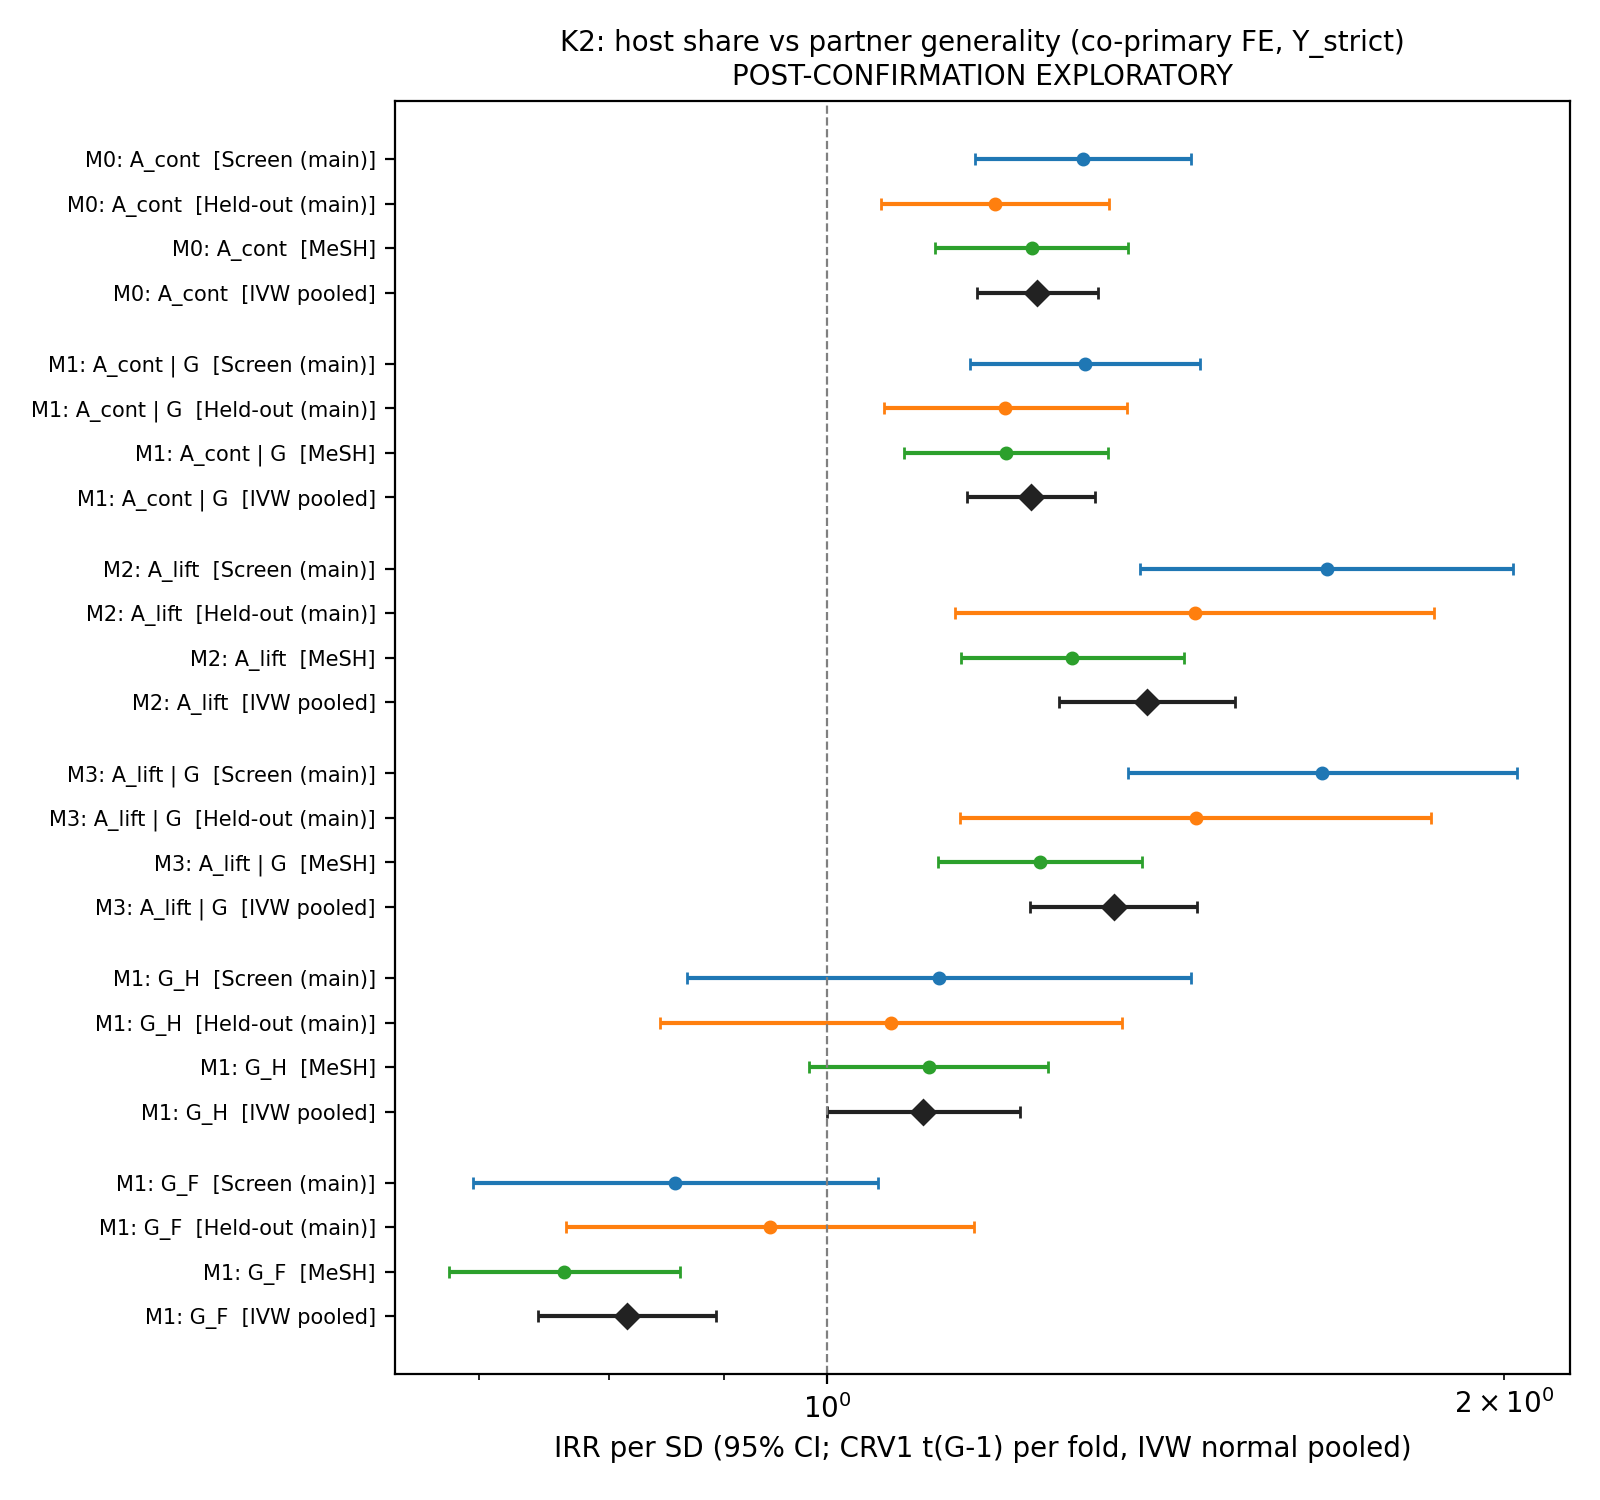

F2_retention


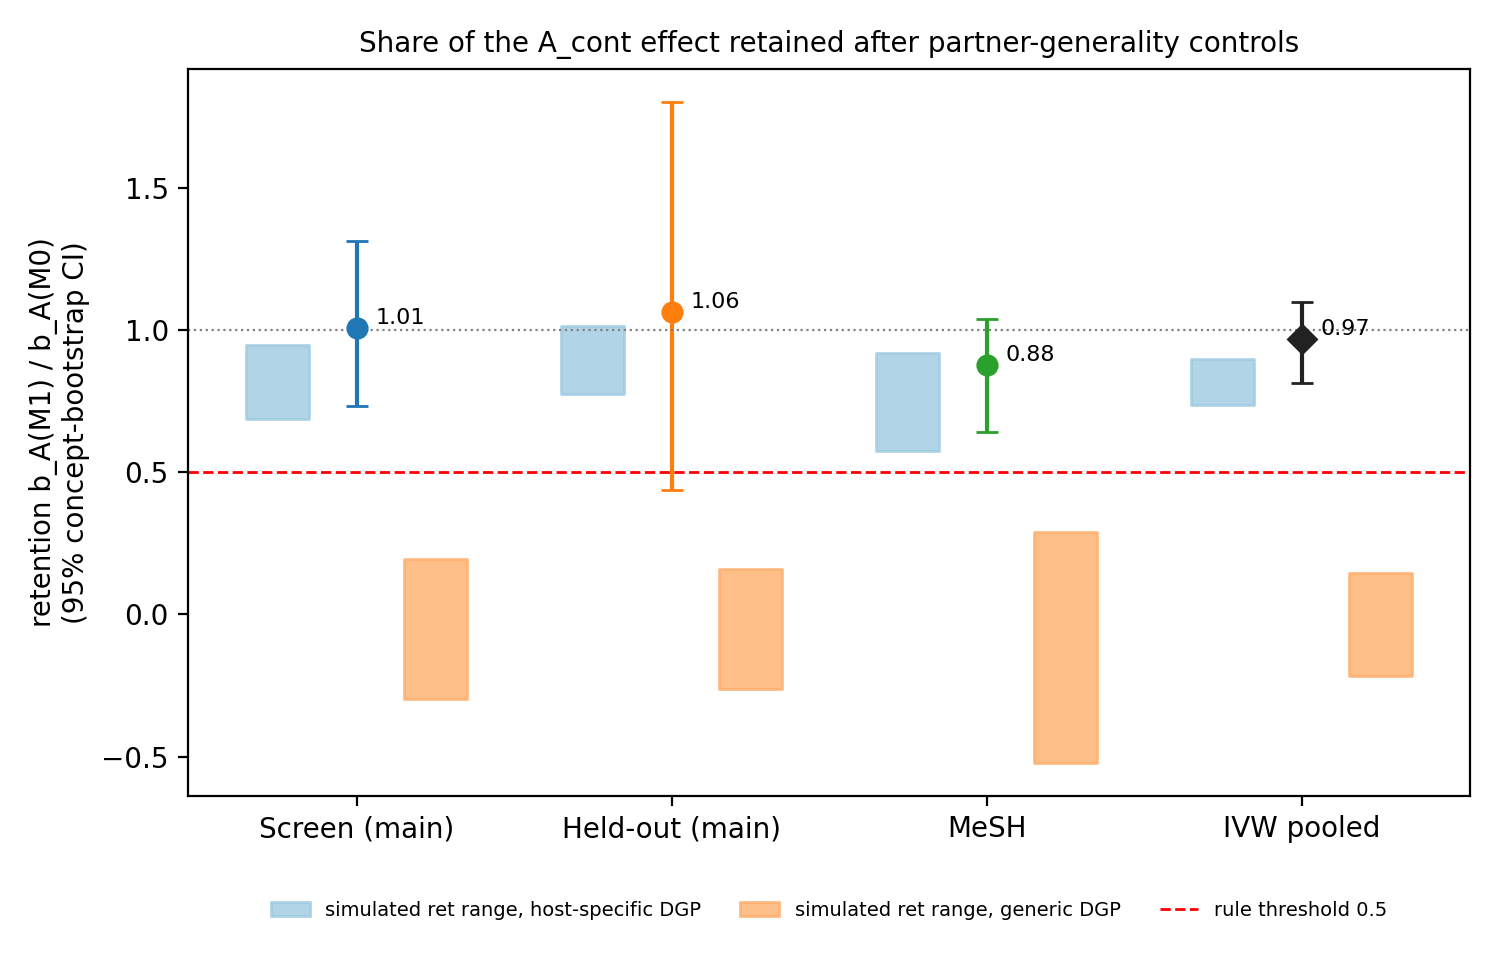

F3_generality_scatter


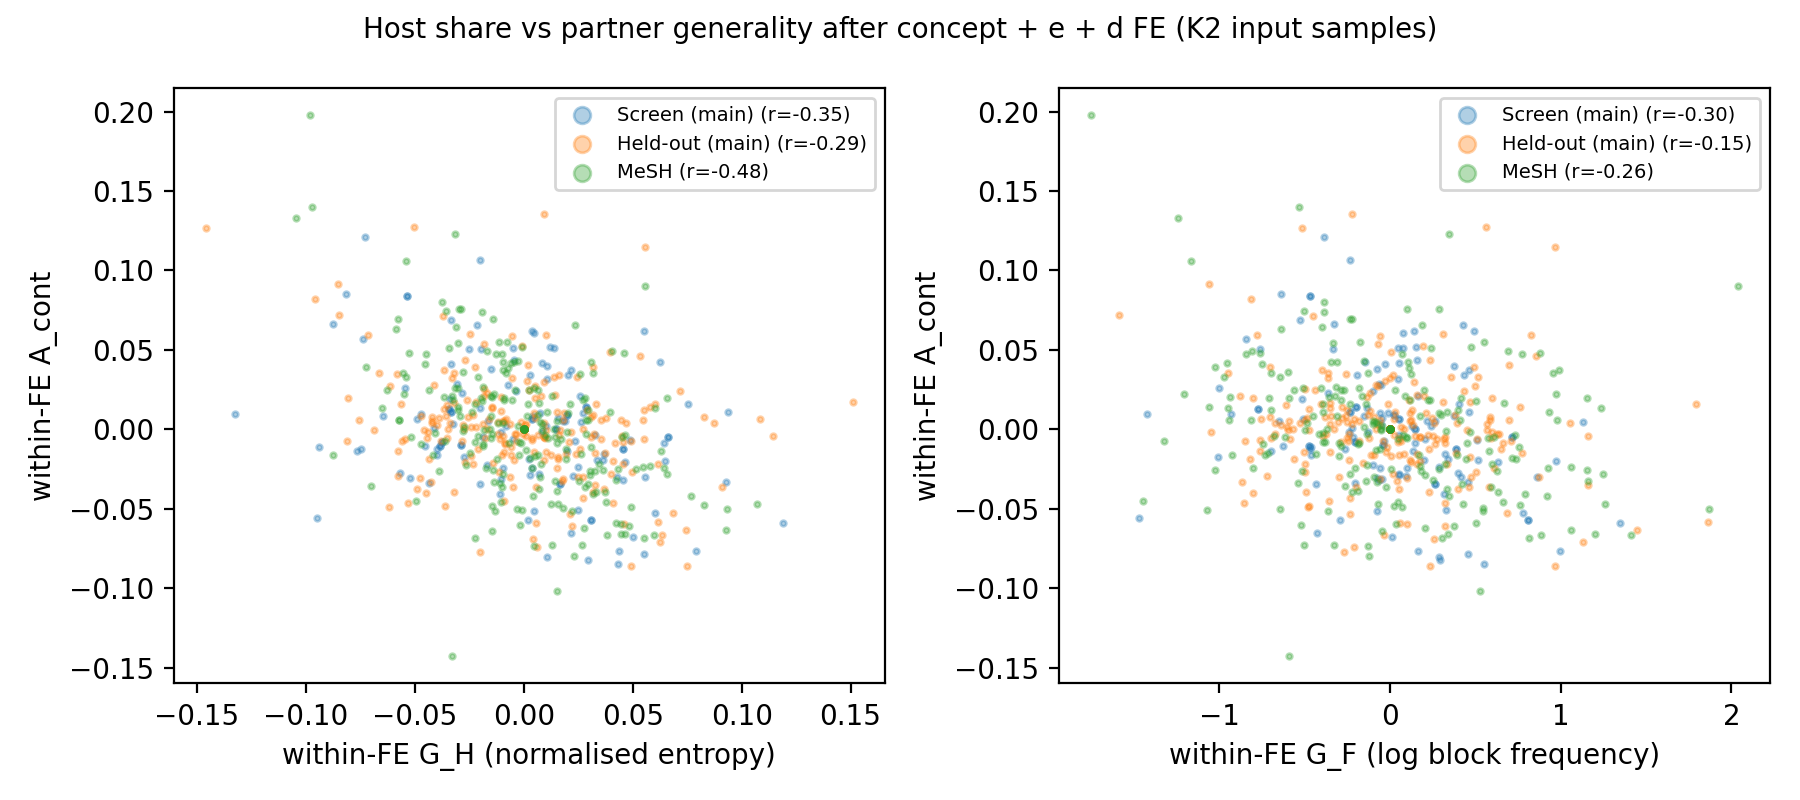

In [14]:
for name in ("F1_k2_forest", "F2_retention", "F3_generality_scatter"):
    print(name)
    display(Image(filename=str(FIGS / f"{name}.png"), width=720))

## Extra summary plot: retention and within-FE correlations
**Left panel:** the per-fold and pooled retention, with the 0.5 threshold of the rule.

**Right panel:** the full-sample within-FE correlations of A_cont with G_H and G_F, taken from the recorded descriptives. They are negative in every fold, which contradicts the generic story's prediction that host share and generality move together.

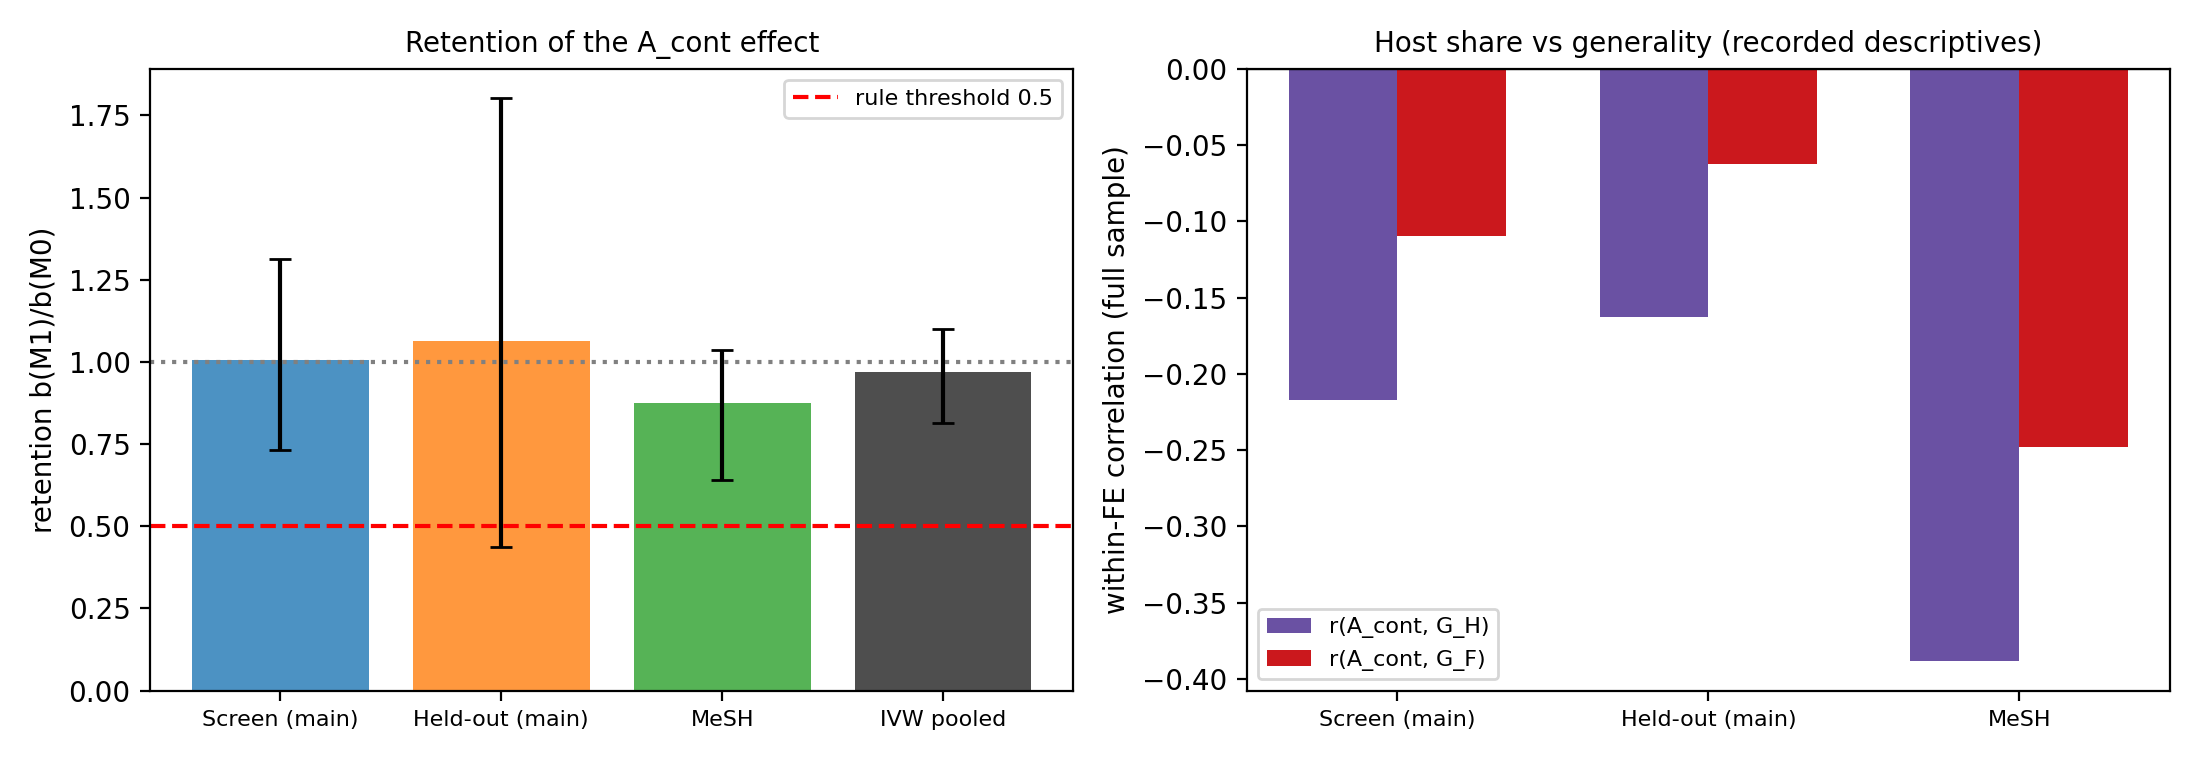

In [15]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.8))
keys = FOLDS + ["pooled"]
ret = [M[f"k2_ret_{k}"] for k in keys]
err = [[M[f"k2_ret_{k}"] - M[f"k2_ret_{k}_lo"] for k in keys], [M[f"k2_ret_{k}_hi"] - M[f"k2_ret_{k}"] for k in keys]]
a1.bar(range(4), ret, color=[COL[k] for k in keys], alpha=0.8)
a1.errorbar(range(4), ret, yerr=err, fmt="none", ecolor="k", capsize=4)
a1.axhline(0.5, color="red", ls="--", label="rule threshold 0.5"); a1.axhline(1, color="grey", ls=":")
a1.set_xticks(range(4)); a1.set_xticklabels([FNAME[k] for k in keys], fontsize=8)
a1.set_ylabel("retention b(M1)/b(M0)"); a1.legend(fontsize=8); a1.set_title("Retention of the A_cont effect", fontsize=10)
x = np.arange(3); w = 0.35
a2.bar(x - w/2, [M[f"k2_{f}_within_r_A_GH"] for f in FOLDS], w, label="r(A_cont, G_H)", color="#6a51a3")
a2.bar(x + w/2, [M[f"k2_{f}_within_r_A_GF"] for f in FOLDS], w, label="r(A_cont, G_F)", color="#cb181d")
a2.axhline(0, color="k", lw=0.8)
a2.set_xticks(x); a2.set_xticklabels([FNAME[f] for f in FOLDS], fontsize=8)
a2.set_ylabel("within-FE correlation (full sample)"); a2.legend(fontsize=8)
a2.set_title("Host share vs generality (recorded descriptives)", fontsize=10)
fig.tight_layout()
fig.savefig(FIGS / "demo_summary.png", dpi=FIG_DPI)
plt.close(fig)
display(Image(filename=str(FIGS / "demo_summary.png"), width=820))